Simulation starting...
Computed step 50/1500 (t = 0.30 s)
Computed step 100/1500 (t = 0.60 s)
Computed step 150/1500 (t = 0.90 s)
Computed step 200/1500 (t = 1.20 s)
Simulation finished.


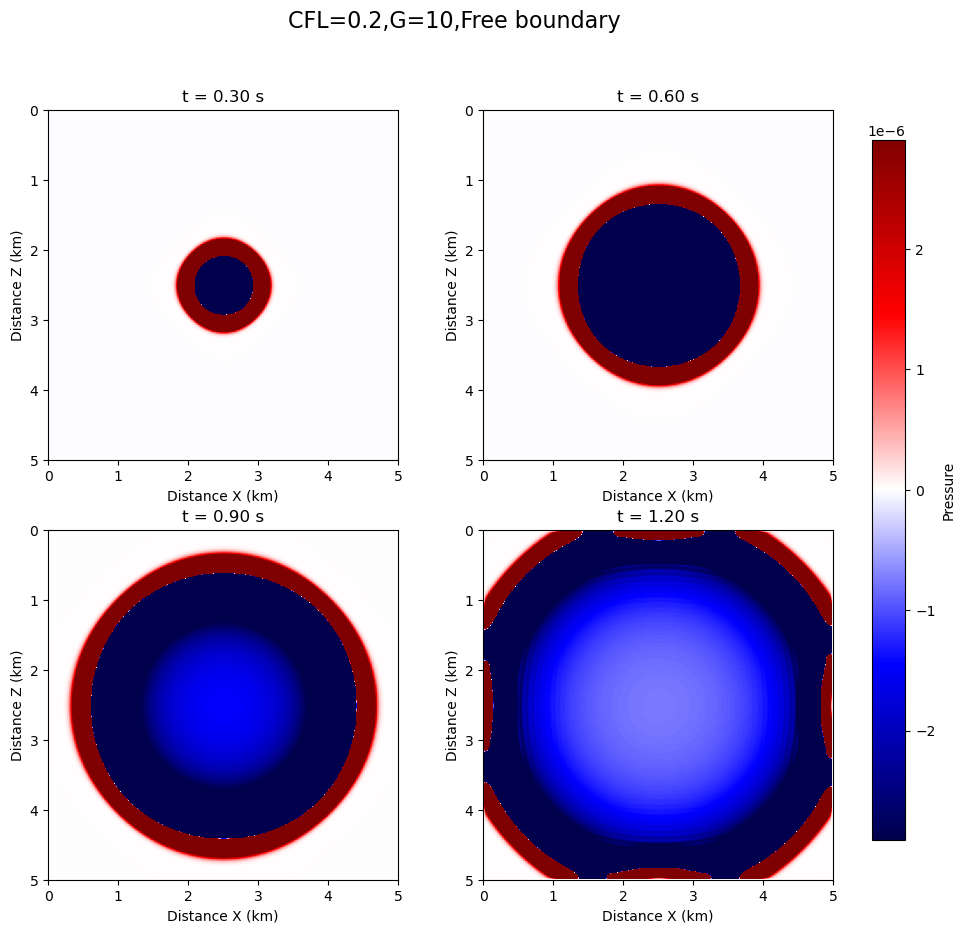

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
# ============================================================================
# 1. Simulation Parameters (Based on provided list)
# ============================================================================
# Grid and Domain Properties
nx, nz = 200, 200          # 7. Overall grid points 400^2
dx, dz = 25, 25        # 6. Grid spacing dx = 12.5m
xmin, xmax = 0, nx * dx    # 2. Dimensions: 5km x 5km
zmin, zmax = 0, nz * dz

# Time and Stability Properties
dt = 0.006               # 8. dt = 0.002s (CFL = 0.6 for c=3000m/s)
tmax = 1.0                 # 9. t max = 1s
nt = 1500                  # 10. Number of time steps

# Velocity Model
# 4. Phase velocity (Range 2500 - 3000 m/s). 
# The image requests a constant velocity. Setting to 2500 m/s to match the 250m dominant wavelength at 10Hz.
c0 = 2500.0               
c = np.full((nx, nz), c0)

# Source Properties
f0 = 10.0                  # 3. Dominant frequency 10 Hz
sx, sz = nx // 2, nz // 2  # Place source in the middle of the domain

# ============================================================================
# 2. Source Function (First Derivative of Gaussian + Boxcar)
# ============================================================================
time = np.arange(nt) * dt
t0 = 1.2 / f0              # Shift to ensure causal start
tau = time - t0

# First derivative of Gaussian
src_pulse = -2 * tau * (np.pi * f0)**2 * np.exp(-(np.pi * f0 * tau)**2)

# Boxcar function to limit the source duration (approx 2.5 periods)
boxcar = np.where((time >= 0) & (time <= 2.5 * t0), 1.0, 0.0)
src = src_pulse * boxcar   # 1. Band-limited function modulated by boxcar

# ============================================================================
# 3. Absorbing Boundary Condition (Sponge Layer)
# ============================================================================
# 11. Absorbing boundary condition implemented via exponential damping (Cerjan)
n_sponge = 40              # Thickness of the sponge layer in grid points
alpha = 0.015              # Damping coefficient
sponge = np.ones((nx, nz))

for i in range(nx):
    for j in range(nz):
        dist_x = max(0, n_sponge - i, i - (nx - 1 - n_sponge))
        dist_z = max(0, n_sponge - j, j - (nz - 1 - n_sponge))
        
        if dist_x > 0 or dist_z > 0:
            dist = max(dist_x, dist_z)
            sponge[i, j] = np.exp(-(alpha * dist)**2)

# ============================================================================
# 4. Finite Difference Simulation Setup
# ============================================================================
# Initialize wavefields: past (p_old), present (p), future (p_new)
p_old = np.zeros((nx, nz))
p = np.zeros((nx, nz))
p_new = np.zeros((nx, nz))


# Precompute squared velocity term
c2_dt2 = (c * dt)**2
dx2 = dx**2
dz2 = dz**2

# ============================================================================
# 5. Time-Stepping Loop
# ============================================================================
print("Simulation starting...")

# Using lists to store a few snapshots to visualize later instead of animating 
# the whole loop to save computation time if run in a standard IDE.
snapshots = []
snapshot_intervals = [50,100,150,200]
'''
for it in range(nt):
    # 2D Laplacian using 3-point operator
    # Vectorized computation for the inner grid points
    d2p_dx2 = (p[2:, 1:-1] - 2 * p[1:-1, 1:-1] + p[:-2, 1:-1]) / dx2
    d2p_dz2 = (p[1:-1, 2:] - 2 * p[1:-1, 1:-1] + p[1:-1, :-2]) / dz2
    
    # Update future wavefield
    p_new[1:-1, 1:-1] = (2 * p[1:-1, 1:-1] - p_old[1:-1, 1:-1] + 
                         c2_dt2[1:-1, 1:-1] * (d2p_dx2 + d2p_dz2))
    
    # Inject source (force term)
    p_new[sx, sz] += src[it] * (dt**2)
    
    # Apply absorbing boundary
    p_new *= sponge
    
    # Update wavefields
    p_old, p, p_new = p, p_new, p_old
'''
for it in range(nt):
    # 3-point operator
    d2p_dx2 = (p[2:, 1:-1] - 2 * p[1:-1, 1:-1] + p[:-2, 1:-1]) / dx2
    d2p_dz2 = (p[1:-1, 2:] - 2 * p[1:-1, 1:-1] + p[1:-1, :-2]) / dz2
    # 5-point operator
    '''
    d2p_dx2 = (-1/12 * p[4:, 2:-2] + 
               4/3  * p[3:-1, 2:-2] - 
            5/2  * p[2:-2, 2:-2] + 
               4/3  * p[1:-3, 2:-2] - 
              1/12 * p[:-4, 2:-2]) / dx2

    d2p_dz2 = (-1/12 * p[2:-2, 4:] + 
                4/3  * p[2:-2, 3:-1] - 
                5/2  * p[2:-2, 2:-2] + 
                4/3  * p[2:-2, 1:-3] - 
               1/12 * p[2:-2, :-4]) / dz2
    '''
    # 6th-order (7-point) spatial derivatives
    '''
    d2p_dx2 = ( 1/90  * p[6:, 3:-3] - 
                3/20  * p[5:-1, 3:-3] + 
                3/2   * p[4:-2, 3:-3] - 
            49/18  * p[3:-3, 3:-3] + 
                3/2   * p[2:-4, 3:-3] - 
                3/20  * p[1:-5, 3:-3] + 
                1/90  * p[:-6, 3:-3]) / dx2

    d2p_dz2 = ( 1/90  * p[3:-3, 6:] - 
                3/20  * p[3:-3, 5:-1] + 
                3/2   * p[3:-3, 4:-2] - 
            49/18  * p[3:-3, 3:-3] + 
                3/2   * p[3:-3, 2:-4] - 
                3/20  * p[3:-3, 1:-5] + 
                1/90  * p[3:-3, :-6]) / dz2
    '''
    # Update for 3-point
    p_new[1:-1, 1:-1] = (2 * p[1:-1, 1:-1] - p_old[1:-1, 1:-1] +c2_dt2[1:-1, 1:-1] * (d2p_dx2 + d2p_dz2))
    # Update for 5-point
    #p_new[2:-2, 2:-2] = (2 * p[2:-2, 2:-2] - p_old[2:-2, 2:-2] + c2_dt2[2:-2, 2:-2] * (d2p_dx2 + d2p_dz2))
    # Update for 7-point
    #p_new[3:-3, 3:-3] = (2 * p[3:-3, 3:-3] - p_old[3:-3, 3:-3] + c2_dt2[3:-3, 3:-3] * (d2p_dx2 + d2p_dz2))
    # Inject source 
    p_new[sx, sz] += src[it] * (dt**2)
    
    # --- APPLY NEW BOUNDARY CONDITIONS HERE ---
    # Apply absorbing boundary
    #p_new *= sponge

    # Apply Free Boundary Condition (all 4 edges)
    p_new[0, :] = 0.0      # Left edge
    p_new[-1, :] = 0.0     # Right edge
    p_new[:, 0] = 0.0      # Top edge (Commonly the only free surface in geophysics)
    p_new[:, -1] = 0.0     # Bottom edge
    
    # Apply Fixed Boundary Condition (all 4 edges)
    #p_new[0, :] = p_new[1, :]      # Left edge
    #p_new[-1, :] = p_new[-2, :]    # Right edge
    #p_new[:, 0] = p_new[:, 1]      # Top edge
    #p_new[:, -1] = p_new[:, -2]    # Bottom edge

    # Update wavefields
    p_old, p, p_new = p, p_new, p_old
    # Save snapshots
    if it in snapshot_intervals:
        snapshots.append(p.copy())
        print(f"Computed step {it}/{nt} (t = {it*dt:.2f} s)")

print("Simulation finished.")

# ============================================================================
# 6. Plotting Results
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(11, 10)) # 宽度稍微加一点给 colorbar 留空间
fig.suptitle("CFL=0.2,G=10,Free boundary", fontsize=16)

# 遍历子图绘制
for i, ax in enumerate(axes.flatten()):
    if i < len(snapshots):
        time_sec = snapshot_intervals[i] * dt
        # 记录 imshow 对象以便创建 colorbar
        im = ax.imshow(snapshots[i].T, cmap='seismic', vmin=-vmax, vmax=vmax, 
                       extent=[0, xmax/1000, zmax/1000, 0])
        ax.set_title(f"t = {time_sec:.2f} s")
        ax.set_xlabel("Distance X (km)")
        ax.set_ylabel("Distance Z (km)")

# 在右侧添加公共颜色棒
# pad 是颜色棒距离子图的间距，shrink 是颜色棒的长度缩放
fig.subplots_adjust(right=0.85) # 给右侧腾出空间
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7]) # [左, 下, 宽, 高]
fig.colorbar(im, cax=cbar_ax, label="Pressure")

plt.show()

## 3点算子

Simulation starting...
Computed step 100/2000 (t = 0.20 s)
Computed step 200/2000 (t = 0.40 s)
Computed step 300/2000 (t = 0.60 s)
Computed step 400/2000 (t = 0.80 s)
Simulation finished.


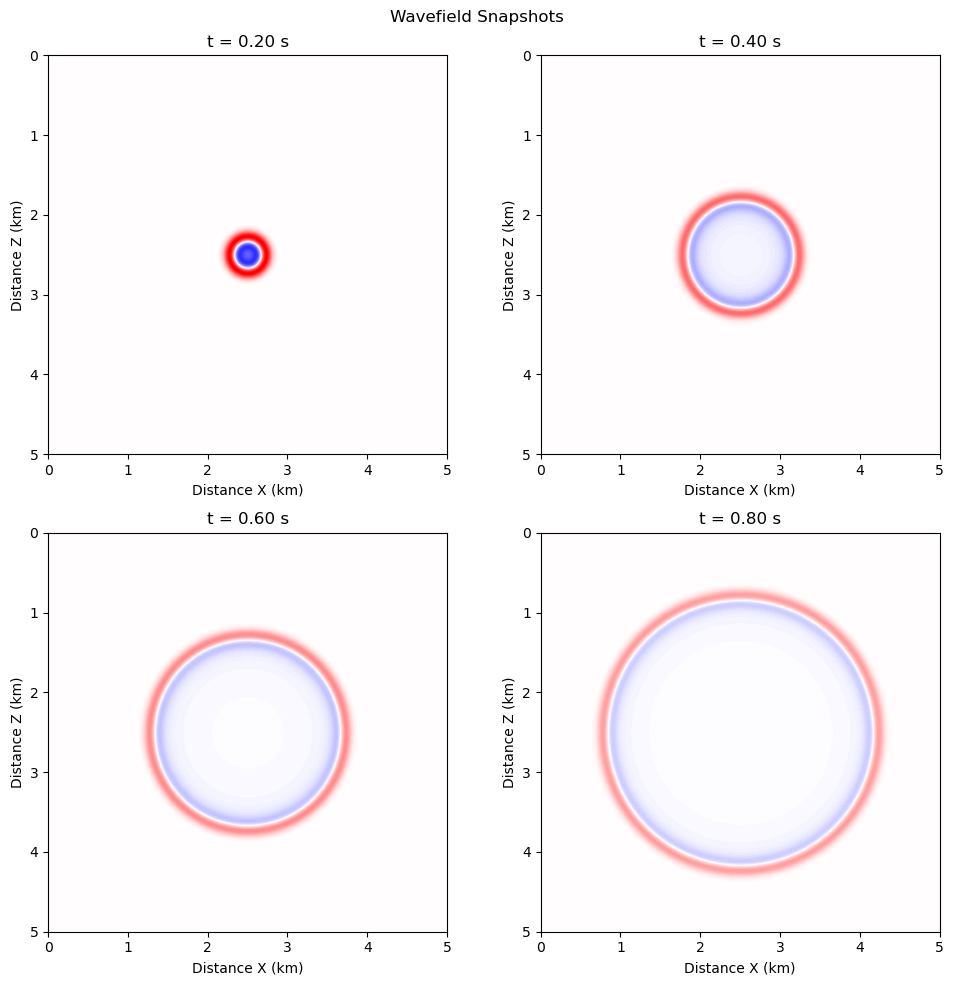

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ============================================================================
# 1. Simulation Parameters (Based on provided list)
# ============================================================================
# Grid and Domain Properties
nx, nz = 500, 500          # 7. Overall grid points 500^2
dx, dz = 10.0, 10.0        # 6. Grid spacing dx = 10m
xmin, xmax = 0, nx * dx    # 2. Dimensions: 5km x 5km
zmin, zmax = 0, nz * dz

# Time and Stability Properties
dt = 0.002                 # 8. dt = 0.002s 
tmax = 4.0                 # 9. t max = 4s
nt = 2000                  # 10. Number of time steps

# Velocity Model
# 4. Phase velocity (Range 2500 - 3000 m/s). 
# The image requests a constant velocity. Setting to 2500 m/s to match the 250m dominant wavelength at 10Hz.
c0 = 2500.0               
c = np.full((nx, nz), c0)

# Source Properties
f0 = 10.0                  # 3. Dominant frequency 10 Hz
sx, sz = nx // 2, nz // 2  # Place source in the middle of the domain

# ============================================================================
# 2. Source Function (First Derivative of Gaussian + Boxcar)
# ============================================================================
time = np.arange(nt) * dt
t0 = 1.2 / f0              # Shift to ensure causal start
tau = time - t0

# First derivative of Gaussian
src_pulse = -2 * tau * (np.pi * f0)**2 * np.exp(-(np.pi * f0 * tau)**2)

# Boxcar function to limit the source duration (approx 2.5 periods)
boxcar = np.where((time >= 0) & (time <= 2.5 * t0), 1.0, 0.0)
src = src_pulse * boxcar   # 1. Band-limited function modulated by boxcar

# ============================================================================
# 3. Absorbing Boundary Condition (Sponge Layer)
# ============================================================================
# 11. Absorbing boundary condition implemented via exponential damping (Cerjan)
n_sponge = 40              # Thickness of the sponge layer in grid points
alpha = 0.015              # Damping coefficient
sponge = np.ones((nx, nz))

for i in range(nx):
    for j in range(nz):
        dist_x = max(0, n_sponge - i, i - (nx - 1 - n_sponge))
        dist_z = max(0, n_sponge - j, j - (nz - 1 - n_sponge))
        
        if dist_x > 0 or dist_z > 0:
            dist = max(dist_x, dist_z)
            sponge[i, j] = np.exp(-(alpha * dist)**2)

# ============================================================================
# 4. Finite Difference Simulation Setup
# ============================================================================
# Initialize wavefields: past (p_old), present (p), future (p_new)
p_old = np.zeros((nx, nz))
p = np.zeros((nx, nz))
p_new = np.zeros((nx, nz))


# Precompute squared velocity term
c2_dt2 = (c * dt)**2
dx2 = dx**2
dz2 = dz**2

# ============================================================================
# 5. Time-Stepping Loop
# ============================================================================
print("Simulation starting...")

# Using lists to store a few snapshots to visualize later instead of animating 
# the whole loop to save computation time if run in a standard IDE.
snapshots = []
snapshot_intervals = [100,200,300,400]

for it in range(nt):
    # 2D Laplacian using 3-point operator
    # Vectorized computation for the inner grid points
    d2p_dx2 = (p[2:, 1:-1] - 2 * p[1:-1, 1:-1] + p[:-2, 1:-1]) / dx2
    d2p_dz2 = (p[1:-1, 2:] - 2 * p[1:-1, 1:-1] + p[1:-1, :-2]) / dz2
    
    # Update future wavefield
    p_new[1:-1, 1:-1] = (2 * p[1:-1, 1:-1] - p_old[1:-1, 1:-1] + 
                         c2_dt2[1:-1, 1:-1] * (d2p_dx2 + d2p_dz2))
    
    # Inject source (force term)
    p_new[sx, sz] += src[it] * (dt**2)
    
    # Apply absorbing boundary
    p_new *= sponge
    
    # Update wavefields
    p_old, p, p_new = p, p_new, p_old
    
    # Save snapshots
    if it in snapshot_intervals:
        snapshots.append(p.copy())
        print(f"Computed step {it}/{nt} (t = {it*dt:.2f} s)")

print("Simulation finished.")

# ============================================================================
# 6. Plotting Results
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle("Wavefield Snapshots")

for i, ax in enumerate(axes.flatten()):
    if i < len(snapshots):
        time_sec = snapshot_intervals[i] * dt
        ax.imshow(snapshots[i].T, cmap='seismic', vmin=-vmax, vmax=vmax, 
                  extent=[0, xmax/1000, zmax/1000, 0])
        ax.set_title(f"t = {time_sec:.2f} s")
        ax.set_xlabel("Distance X (km)")
        ax.set_ylabel("Distance Z (km)")

plt.tight_layout()
plt.show()

## 5点算子

Simulation starting...
Computed step 89/2000 (t = 0.25 s)
Computed step 178/2000 (t = 0.50 s)
Computed step 267/2000 (t = 0.75 s)
Computed step 356/2000 (t = 1.00 s)
Simulation finished.


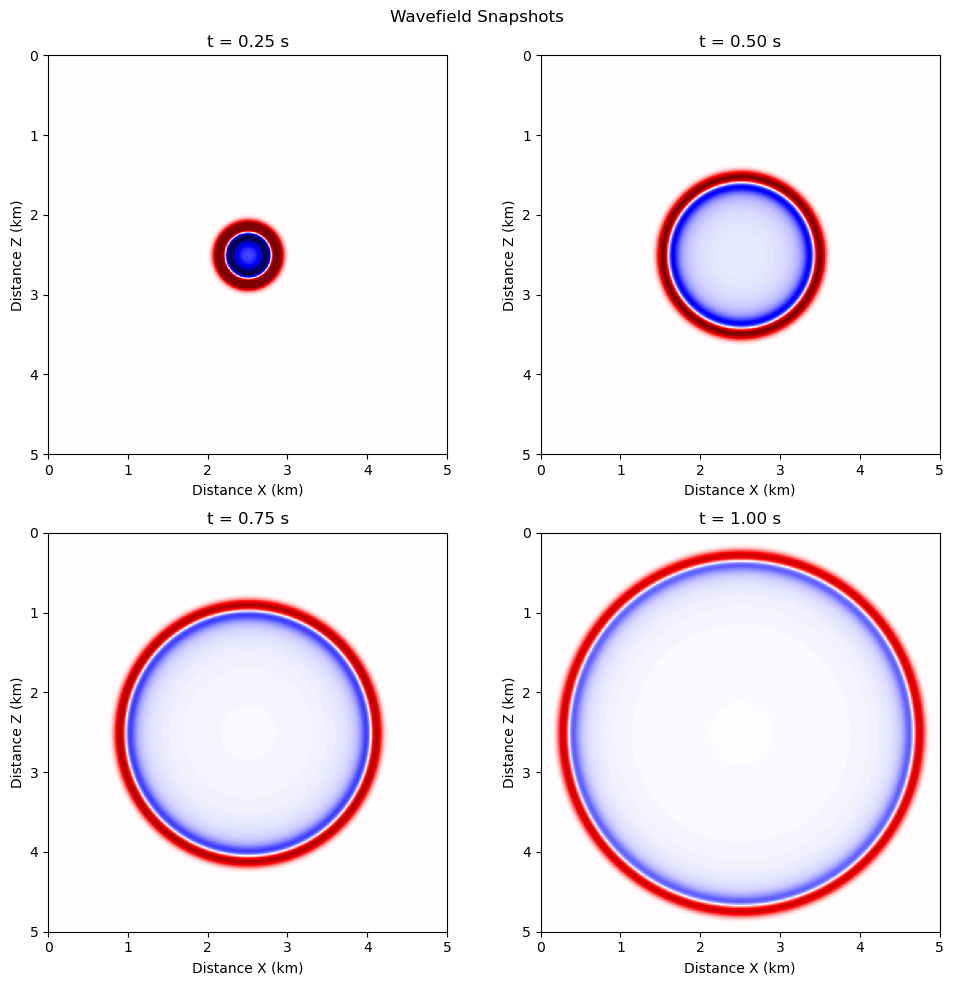

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ============================================================================
# 1. Simulation Parameters (Based on provided list)
# ============================================================================
# Grid and Domain Properties
nx, nz = 250, 250          # 7. Overall grid points 500^2
dx, dz = 20.0, 20.0        # 6. Grid spacing dx = 10m
xmin, xmax = 0, nx * dx    # 2. Dimensions: 5km x 5km
zmin, zmax = 0, nz * dz

# Time and Stability Properties
dt = 0.0028                 # 8. dt = 0.002s 
tmax = 4.0                 # 9. t max = 4s
nt = 2000                  # 10. Number of time steps

# Velocity Model
# 4. Phase velocity (Range 2500 - 3000 m/s). 
# The image requests a constant velocity. Setting to 2500 m/s to match the 250m dominant wavelength at 10Hz.
c0 = 2500.0               
c = np.full((nx, nz), c0)

# Source Properties
f0 = 10.0                  # 3. Dominant frequency 10 Hz
sx, sz = nx // 2, nz // 2  # Place source in the middle of the domain

# ============================================================================
# 2. Source Function (First Derivative of Gaussian + Boxcar)
# ============================================================================
time = np.arange(nt) * dt
t0 = 1.2 / f0              # Shift to ensure causal start
tau = time - t0

# First derivative of Gaussian
src_pulse = -2 * tau * (np.pi * f0)**2 * np.exp(-(np.pi * f0 * tau)**2)

# Boxcar function to limit the source duration (approx 2.5 periods)
boxcar = np.where((time >= 0) & (time <= 2.5 * t0), 1.0, 0.0)
src = src_pulse * boxcar   # 1. Band-limited function modulated by boxcar

# ============================================================================
# 3. Absorbing Boundary Condition (Sponge Layer)
# ============================================================================
# 11. Absorbing boundary condition implemented via exponential damping (Cerjan)
n_sponge = 40              # Thickness of the sponge layer in grid points
alpha = 0.015              # Damping coefficient
sponge = np.ones((nx, nz))

for i in range(nx):
    for j in range(nz):
        dist_x = max(0, n_sponge - i, i - (nx - 1 - n_sponge))
        dist_z = max(0, n_sponge - j, j - (nz - 1 - n_sponge))
        
        if dist_x > 0 or dist_z > 0:
            dist = max(dist_x, dist_z)
            sponge[i, j] = np.exp(-(alpha * dist)**2)

# ============================================================================
# 4. Finite Difference Simulation Setup
# ============================================================================
# Initialize wavefields: past (p_old), present (p), future (p_new)
p_old = np.zeros((nx, nz))
p = np.zeros((nx, nz))
p_new = np.zeros((nx, nz))


# Precompute squared velocity term
c2_dt2 = (c * dt)**2
dx2 = dx**2
dz2 = dz**2

# ============================================================================
# 5. Time-Stepping Loop
# ============================================================================
print("Simulation starting...")

# Using lists to store a few snapshots to visualize later instead of animating 
# the whole loop to save computation time if run in a standard IDE.
snapshots = []
snapshot_intervals = [89,178,267,356]

for it in range(nt):
    # 2D Laplacian using 3-point operator
    # Vectorized computation for the inner grid points
    d2p_dx2 = (-1/12 * p[4:, 2:-2] + 
               4/3  * p[3:-1, 2:-2] - 
            5/2  * p[2:-2, 2:-2] + 
               4/3  * p[1:-3, 2:-2] - 
              1/12 * p[:-4, 2:-2]) / dx2

    d2p_dz2 = (-1/12 * p[2:-2, 4:] + 
                4/3  * p[2:-2, 3:-1] - 
                5/2  * p[2:-2, 2:-2] + 
                4/3  * p[2:-2, 1:-3] - 
               1/12 * p[2:-2, :-4]) / dz2
    
    # Update future wavefield
    p_new[2:-2, 2:-2] = (2 * p[2:-2, 2:-2] - p_old[2:-2, 2:-2] + c2_dt2[2:-2, 2:-2] * (d2p_dx2 + d2p_dz2))
    
    # Inject source (force term)
    p_new[sx, sz] += src[it] * (dt**2)
    
    # Apply absorbing boundary
    #p_new *= sponge
    p_new[0, :] = 0.0      # Left edge
    p_new[-1, :] = 0.0     # Right edge
    p_new[:, 0] = 0.0      # Top edge (Commonly the only free surface in geophysics)
    p_new[:, -1] = 0.0     # Bottom edge
    
    # Update wavefields
    p_old, p, p_new = p, p_new, p_old
    
    # Save snapshots
    if it in snapshot_intervals:
        snapshots.append(p.copy())
        print(f"Computed step {it}/{nt} (t = {it*dt:.2f} s)")

print("Simulation finished.")

# ============================================================================
# 6. Plotting Results
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle("Wavefield Snapshots")

for i, ax in enumerate(axes.flatten()):
    if i < len(snapshots):
        time_sec = snapshot_intervals[i] * dt
        ax.imshow(snapshots[i].T, cmap='seismic', vmin=-vmax, vmax=vmax, 
                  extent=[0, xmax/1000, zmax/1000, 0])
        ax.set_title(f"t = {time_sec:.2f} s")
        ax.set_xlabel("Distance X (km)")
        ax.set_ylabel("Distance Z (km)")

plt.tight_layout()
plt.show()

## 7点算子

Simulation starting...
Computed step 100/2000 (t = 0.20 s)
Computed step 200/2000 (t = 0.40 s)
Computed step 300/2000 (t = 0.60 s)
Computed step 400/2000 (t = 0.80 s)
Simulation finished.


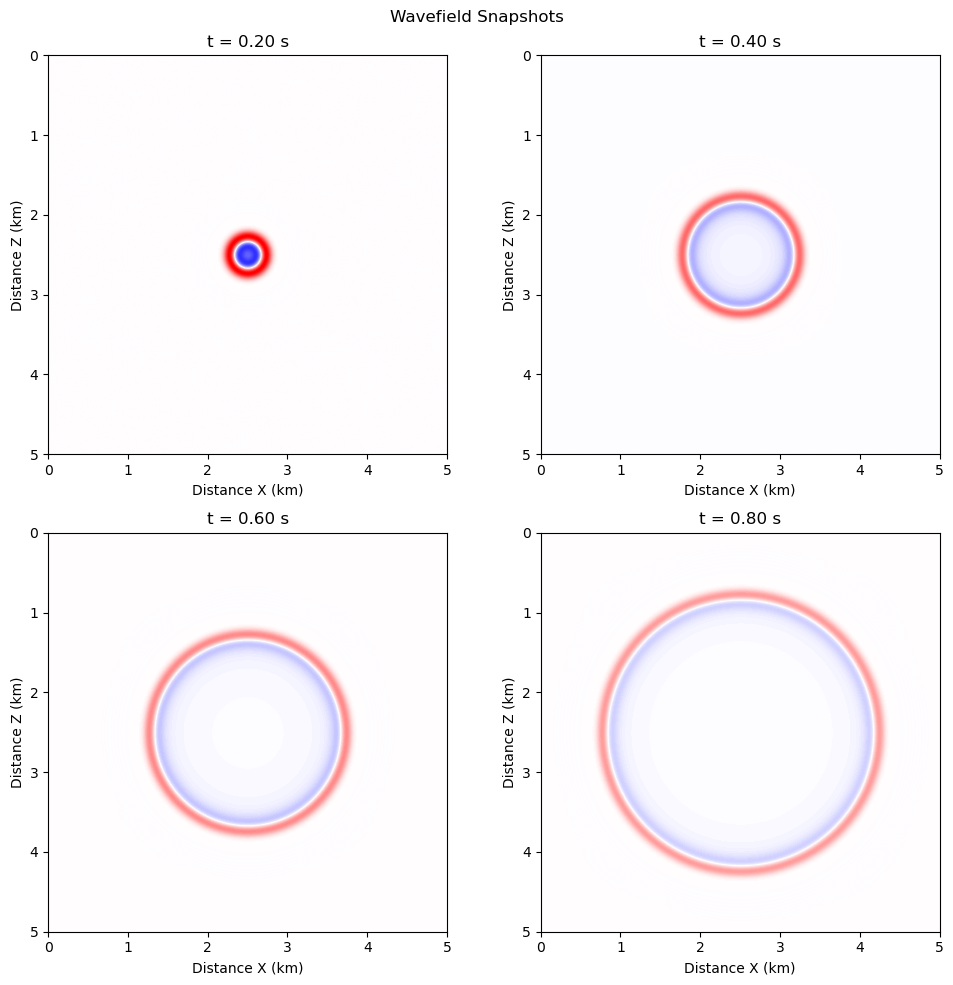

In [117]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ============================================================================
# 1. Simulation Parameters (Based on provided list)
# ============================================================================
# Grid and Domain Properties
nx, nz = 500, 500          # 7. Overall grid points 500^2
dx, dz = 10.0, 10.0        # 6. Grid spacing dx = 10m
xmin, xmax = 0, nx * dx    # 2. Dimensions: 5km x 5km
zmin, zmax = 0, nz * dz

# Time and Stability Properties
dt = 0.002                 # 8. dt = 0.002s 
tmax = 4.0                 # 9. t max = 4s
nt = 2000                  # 10. Number of time steps

# Velocity Model
# 4. Phase velocity (Range 2500 - 3000 m/s). 
# The image requests a constant velocity. Setting to 2500 m/s to match the 250m dominant wavelength at 10Hz.
c0 = 2500.0               
c = np.full((nx, nz), c0)

# Source Properties
f0 = 10.0                  # 3. Dominant frequency 10 Hz
sx, sz = nx // 2, nz // 2  # Place source in the middle of the domain

# ============================================================================
# 2. Source Function (First Derivative of Gaussian + Boxcar)
# ============================================================================
time = np.arange(nt) * dt
t0 = 1.2 / f0              # Shift to ensure causal start
tau = time - t0

# First derivative of Gaussian
src_pulse = -2 * tau * (np.pi * f0)**2 * np.exp(-(np.pi * f0 * tau)**2)

# Boxcar function to limit the source duration (approx 2.5 periods)
boxcar = np.where((time >= 0) & (time <= 2.5 * t0), 1.0, 0.0)
src = src_pulse * boxcar   # 1. Band-limited function modulated by boxcar

# ============================================================================
# 3. Absorbing Boundary Condition (Sponge Layer)
# ============================================================================
# 11. Absorbing boundary condition implemented via exponential damping (Cerjan)
n_sponge = 40              # Thickness of the sponge layer in grid points
alpha = 0.015              # Damping coefficient
sponge = np.ones((nx, nz))

for i in range(nx):
    for j in range(nz):
        dist_x = max(0, n_sponge - i, i - (nx - 1 - n_sponge))
        dist_z = max(0, n_sponge - j, j - (nz - 1 - n_sponge))
        
        if dist_x > 0 or dist_z > 0:
            dist = max(dist_x, dist_z)
            sponge[i, j] = np.exp(-(alpha * dist)**2)

# ============================================================================
# 4. Finite Difference Simulation Setup
# ============================================================================
# Initialize wavefields: past (p_old), present (p), future (p_new)
p_old = np.zeros((nx, nz))
p = np.zeros((nx, nz))
p_new = np.zeros((nx, nz))


# Precompute squared velocity term
c2_dt2 = (c * dt)**2
dx2 = dx**2
dz2 = dz**2

# ============================================================================
# 5. Time-Stepping Loop
# ============================================================================
print("Simulation starting...")

# Using lists to store a few snapshots to visualize later instead of animating 
# the whole loop to save computation time if run in a standard IDE.
snapshots = []
snapshot_intervals = [100,200,300,400]

for it in range(nt):
    # 2D Laplacian using 3-point operator
    # Vectorized computation for the inner grid points
    d2p_dx2 = ( 1/90  * p[6:, 3:-3] - 
                3/20  * p[5:-1, 3:-3] + 
                3/2   * p[4:-2, 3:-3] - 
            49/18  * p[3:-3, 3:-3] + 
                3/2   * p[2:-4, 3:-3] - 
                3/20  * p[1:-5, 3:-3] + 
                1/90  * p[:-6, 3:-3]) / dx2

    d2p_dz2 = ( 1/90  * p[3:-3, 6:] - 
                3/20  * p[3:-3, 5:-1] + 
                3/2   * p[3:-3, 4:-2] - 
            49/18  * p[3:-3, 3:-3] + 
                3/2   * p[3:-3, 2:-4] - 
                3/20  * p[3:-3, 1:-5] + 
                1/90  * p[3:-3, :-6]) / dz2
    
    # Update future wavefield
    p_new[3:-3, 3:-3] = (2 * p[3:-3, 3:-3] - p_old[3:-3, 3:-3] + c2_dt2[3:-3, 3:-3] * (d2p_dx2 + d2p_dz2))
    
    # Inject source (force term)
    p_new[sx, sz] += src[it] * (dt**2)
    
    # Apply absorbing boundary
    #p_new *= sponge
    p_new[0, :] = 0.0      # Left edge
    p_new[-1, :] = 0.0     # Right edge
    p_new[:, 0] = 0.0      # Top edge (Commonly the only free surface in geophysics)
    p_new[:, -1] = 0.0     # Bottom edge
    
    # Update wavefields
    p_old, p, p_new = p, p_new, p_old
    
    # Save snapshots
    if it in snapshot_intervals:
        snapshots.append(p.copy())
        print(f"Computed step {it}/{nt} (t = {it*dt:.2f} s)")

print("Simulation finished.")

# ============================================================================
# 6. Plotting Results
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle("Wavefield Snapshots")

for i, ax in enumerate(axes.flatten()):
    if i < len(snapshots):
        time_sec = snapshot_intervals[i] * dt
        ax.imshow(snapshots[i].T, cmap='seismic', vmin=-vmax, vmax=vmax, 
                  extent=[0, xmax/1000, zmax/1000, 0])
        ax.set_title(f"t = {time_sec:.2f} s")
        ax.set_xlabel("Distance X (km)")
        ax.set_ylabel("Distance Z (km)")

plt.tight_layout()
plt.show()